# Полный каузальный пайплайн на синтетических данных
## Сравнение MSE каузальных моделей vs ML при наличии вмешательства (intervention)

**Источник данных:** `synthetic_data/` — CSV из `synthetic_causal_data.ipynb`

**Цель:** применить логику 5 скриптов (`step1`–`step5`) к трём сценариям  
и построить таблицу восстановления истинного каузального эффекта θ*.

| Сценарий | Структура | θ* | Вмешательство |
|----------|-----------|-----|---------------|
| 1 | Линейный VAR(1): C→X, C→Y, X→Y | **0.8** | X[t₀] += Δ ≈ +2σ |
| 2 | SETAR (пороговый): β=0.5/1.5 | **0.5 / 1.5** | нет |
| 3 | Латентный конфаундер U (ненабл.) | **0.7** | нет |

## 0. Импорты и конфигурация

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from typing import List, Dict, Tuple, Optional

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

from sklearn.linear_model import Ridge, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

SEED        = 42
TRAIN_RATIO = 0.75      # 75% обучение / 25% тест
T0          = 300       # момент вмешательства (Сценарий 1)
DATA_DIR    = Path('synthetic_data')

# Истинные каузальные эффекты
TRUE_EFFECTS = {
    'scenario1': {'theta_XY': 0.8,  'theta_CY': -0.3},
    'scenario2': {'beta_low': 0.5,  'beta_high': 1.5},
    'scenario3': {'theta_XY': 0.7},
}

np.random.seed(SEED)
plt.rcParams.update({'figure.dpi':120, 'font.size':11, 'axes.titlesize':12})
print('Готово. DATA_DIR:', DATA_DIR.resolve())
print('Файлов:', len(list(DATA_DIR.glob('*.csv'))))

Готово. DATA_DIR: D:\Образование\Магистратура\Диплом\ITMO_VKR\ITMO_VKR\syntetic data\synthetic_data
Файлов: 51


---
## STEP 1 — DAG Definition

Адаптируем структуру `AssetDAG` из `step1_dag_definitions.py` под синтетические сценарии.

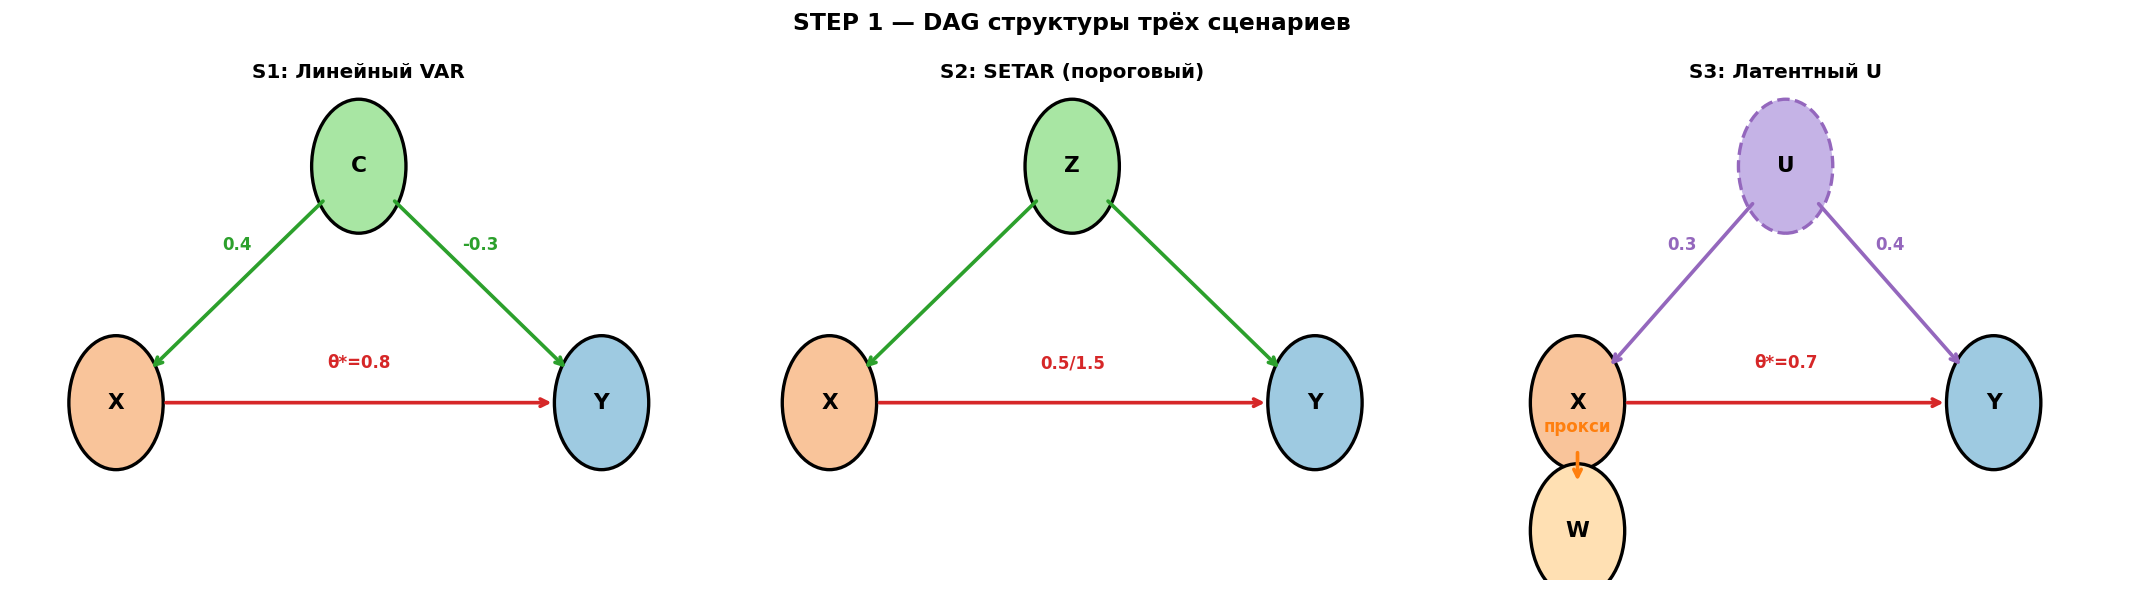

DAG определены для всех трёх сценариев.


In [2]:
from dataclasses import dataclass, field

@dataclass
class SyntheticDAG:
    """Аналог AssetDAG из step1_dag_definitions.py для синтетических данных."""
    name:        str
    target:      str
    causes:      List[str]
    confounders: List[str]
    mediators:   List[str]
    instruments: List[str]
    true_effect: Dict[str, float]
    notes:       str = ''

# ── Сценарий 1: C→X, C→Y, X→Y ───────────────────────────────────────────────
DAG_S1 = SyntheticDAG(
    name        = 'Scenario1_LinearVAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['C'],          # C — backdoor конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'X_lag1': 0.8, 'C_lag1': -0.3, 'Y_lag1': 0.2},
    notes       = 'Backdoor: X←C→Y. Без C оценка θ(X→Y) смещена.'
)

# ── Сценарий 2: SETAR — пороговый эффект ─────────────────────────────────────
DAG_S2 = SyntheticDAG(
    name        = 'Scenario2_SETAR',
    target      = 'Y',
    causes      = ['X'],
    confounders = ['Z'],          # Z — наблюдаемый конфаундер
    mediators   = [],
    instruments = [],
    true_effect = {'beta_low': 0.5, 'beta_high': 1.5},
    notes       = 'Нелинейный эффект: β=0.5 при |X|<1, β=1.5 при |X|≥1'
)

# ── Сценарий 3: латентный конфаундер U ───────────────────────────────────────
DAG_S3 = SyntheticDAG(
    name        = 'Scenario3_LatentConfounder',
    target      = 'Y',
    causes      = ['X'],
    confounders = [],             # U ненаблюдаем! W — прокси
    mediators   = [],
    instruments = ['W'],         # W — прокси для U
    true_effect = {'X_lag1': 0.7},
    notes       = 'U — латентный конфаундер. W=rolling_vol(X) — прокси. Смещение при игнорировании U.'
)

ALL_DAGS = {'scenario1': DAG_S1, 'scenario2': DAG_S2, 'scenario3': DAG_S3}

# ── Визуализация DAG ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('STEP 1 — DAG структуры трёх сценариев', fontsize=14, fontweight='bold')

dags_viz = [
    ('S1: Линейный VAR',
     {'C':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('C','X','0.4','#2ca02c'),('C','Y','-0.3','#2ca02c'),('X','Y','θ*=0.8','#d62728')]),
    ('S2: SETAR (пороговый)',
     {'Z':(5,4.2,'#a8e6a3'),'X':(1.5,1.8,'#f9c49a'),'Y':(8.5,1.8,'#9ecae1')},
     [('Z','X','','#2ca02c'),('Z','Y','','#2ca02c'),('X','Y','0.5/1.5','#d62728')]),
    ('S3: Латентный U',
     {'U':(5,4.2,'#c5b3e6'),'X':(2,1.8,'#f9c49a'),'Y':(8,1.8,'#9ecae1'),'W':(2,0.5,'#ffe0b3')},
     [('U','X','0.3','#9467bd'),('U','Y','0.4','#9467bd'),
      ('X','Y','θ*=0.7','#d62728'),('X','W','прокси','#ff7f0e')]),
]
for ax,(title,nodes,edges) in zip(axes,dags_viz):
    ax.set_xlim(0,10); ax.set_ylim(0,5); ax.axis('off')
    ax.set_title(title, fontweight='bold')
    for name,(x,y,col) in nodes.items():
        style = '--' if name=='U' else '-'
        ec = '#9467bd' if name=='U' else 'black'
        ax.add_patch(plt.Circle((x,y),0.68,color=col,ec=ec,lw=2,ls=style,zorder=3))
        ax.text(x,y,name,ha='center',va='center',fontsize=13,fontweight='bold',zorder=4)
    for s,d,lbl,col in edges:
        sx,sy,_=nodes[s]; dx,dy,_=nodes[d]
        ax.annotate('',xy=(dx,dy),xytext=(sx,sy),
            arrowprops=dict(arrowstyle='->',lw=2.2,color=col,shrinkA=30,shrinkB=30))
        if lbl:
            ax.text((sx+dx)/2,(sy+dy)/2+0.35,lbl,ha='center',fontsize=10,
                    color=col,fontweight='bold')

plt.tight_layout(); plt.show()
print('DAG определены для всех трёх сценариев.')

---
## STEP 2 — Загрузка данных и отбор переменных

**Логика из `step2_variable_selection.py`:**
- Метод A: LassoCV (эвристический)
- Метод B: Backdoor criterion (экспертный DAG)
- ADF тест стационарности

In [6]:
# ── Загрузка всех реализаций ─────────────────────────────────────────────────
def load_scenario(scenario: str, n_real: int = 10, suffix: str = '') -> List[pd.DataFrame]:
    """Загружает N реализаций сценария из synthetic_data/"""
    frames = []
    for i in range(1, n_real+1):
        fname = f'{scenario}_realization_{i:02d}{suffix}.csv'
        p = DATA_DIR / fname
        if p.exists():
            df = pd.read_csv(p, index_col=0)
            df.index = pd.RangeIndex(len(df))
            frames.append(df)
    return frames

# ── ADF тест ─────────────────────────────────────────────────────────────────
def adf_pval(series):
    try: return adfuller(series.dropna(), autolag='AIC')[1]
    except: return 1.0

def check_stationarity(df: pd.DataFrame, cols: List[str]) -> Dict[str, bool]:
    """Возвращает словарь {col: is_stationary}"""
    result = {}
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            result[col] = p < 0.05
    return result

# ── Приведение к стационарности (только если нужно) ─────────────────────────
def make_stationary(df: pd.DataFrame, target: str, force_diff: bool = False) -> pd.DataFrame:
    """Приводит к стационарности только нестационарные ряды."""
    result = {}
    for col in df.columns:
        s = df[col].dropna()
        if len(s) < 20:
            continue
        if force_diff or not check_stationarity(df, [col])[col]:
            # Используем diff() только для явно нестационарных
            result[col] = df[col].diff()
        else:
            result[col] = df[col]
    return pd.DataFrame(result).dropna()

# ── Метод B: Экспертный backdoor ─────────────────────────────────────────────
def select_expert_backdoor(dag: SyntheticDAG) -> List[str]:
    return [z for z in dag.confounders if z not in dag.mediators]

# ── Загружаем и анализируем ──────────────────────────────────────────────────
s1_frames = load_scenario('scenario1', 10)
s2_frames = load_scenario('scenario2', 10)
s3_frames = load_scenario('scenario3', 10, suffix='_observed')

# Основной датафрейм — первая реализация каждого сценария
df1 = s1_frames[0].copy()
df2 = s2_frames[0].copy()
df3 = s3_frames[0].copy()

print(f'Загружено реализаций: S1={len(s1_frames)}, S2={len(s2_frames)}, S3={len(s3_frames)}')
print()

# ADF тесты
for name, df, cols in [('S1', df1, ['Y','X','C']),
                        ('S2', df2, ['Y','X','Z']),
                        ('S3', df3, ['Y','X','W'])]:
    print(f'{name} — ADF тест:')
    for col in cols:
        if col in df.columns:
            p = adf_pval(df[col])
            p = adf_pval(df[col])
            status = "стационарен" if p < 0.05 else "нестационарен → возможен diff"
            print(f'  {col}: p={p:.4f} — {status}')
    print()

Загружено реализаций: S1=10, S2=10, S3=10

S1 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  C: p=0.0000 — стационарен

S2 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  Z: p=0.0000 — стационарен

S3 — ADF тест:
  Y: p=0.0000 — стационарен
  X: p=0.0000 — стационарен
  W: p=0.0000 — стационарен



In [7]:
# ── Отбор переменных по всем методам ────────────────────────────────────────
var_selection = {}

for scenario, dag, df in [('scenario1', DAG_S1, df1),
                            ('scenario2', DAG_S2, df2),
                            ('scenario3', DAG_S3, df3)]:
    df_stat = df.copy()
    all_cands = [c for c in df_stat.columns if c != dag.target]

    expert    = select_expert_backdoor(dag)
    # Для S3: expert пустой (U не наблюдаем), добавляем прокси W
    if scenario == 'scenario3':
        expert_with_proxy = expert + [c for c in dag.instruments if c in df_stat.columns]
    else:
        expert_with_proxy = expert

    var_selection[scenario] = {
        'dag':       dag,
        'df':        df,
        'df_stat':   df_stat,
        'expert':    expert_with_proxy,
        'causes':    dag.causes,
    }
    print(f'{scenario}:')
    print(f'  Expert (backdoor)  : {expert_with_proxy}')
    print()

scenario1:
  Expert (backdoor)  : ['C']

scenario2:
  Expert (backdoor)  : ['Z']

scenario3:
  Expert (backdoor)  : ['W']



---
## STEP 3 — Каузальные модели

**Методы из `step3_causal_models.py`:**
1. **SCM / OLS+backdoor** — правильная спецификация с контролем конфаундеров
2. **DML** — Double Machine Learning, partialling-out с cross-fitting
3. **VAR + Granger** — VAR(p) с отбором значимых переменных
4. **IV-2SLS** — инструментальные переменные (Сценарий 3: W как инструмент)

In [26]:
# ── Общие утилиты ─────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label=''):
    mask = ~(np.isnan(y_true)|np.isnan(y_pred))
    yt,yp = y_true[mask], y_pred[mask]
    if len(yt)==0: return {'RMSE':np.nan,'MAE':np.nan,'MAPE':np.nan,'R2':np.nan}
    rmse = np.sqrt(mean_squared_error(yt,yp))
    mae  = mean_absolute_error(yt,yp)
    mape = np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-9)))*100
    r2   = r2_score(yt,yp)
    return {'RMSE':round(rmse,6),'MAE':round(mae,6),'MAPE':round(mape,4),'R2':round(r2,4)}

def make_lag_features(df, target, controls, n_lags=2):
    all_vars = [target] + [c for c in controls if c in df.columns]
    feat = {}
    for lag in range(1, n_lags+1):
        for v in all_vars:
            feat[f'{v}_lag{lag}'] = df[v].shift(lag)
    fd = pd.DataFrame(feat).dropna()
    y  = df[target].loc[fd.index]
    return fd, y

def ts_split(X, y, ratio=TRAIN_RATIO):
    n = len(X); cut = int(n*ratio)
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:]

# ── МЕТОД 1: SCM / OLS + backdoor ────────────────────────────────────────────
def run_scm_ols(df, target, controls, causes):
    """OLS с полным backdoor adjustment set."""
    all_ctrl = list(dict.fromkeys(causes+controls))                 # Формирование набора контрольных переменных
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)       # Создание лаговых признаков
    # Проверка достаточности данных
    if len(fd) < 60: 
        return {'method':'SCM_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    model = OLS(y_tr, add_constant(X_tr)).fit()
    y_pred = model.predict(add_constant(X_te))
    cause_col = f'{causes[0]}_lag1' if f'{causes[0]}_lag1' in fd.columns else None
    theta = float(model.params.get(cause_col, np.nan)) if cause_col else np.nan
    return {'method':'SCM_OLS',
            'metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta,
            'preds':y_pred,
            'y_true':y_te.values}

# ── МЕТОД 2: DML — partialling-out ───────────────────────────────────────────
def run_dml(df, target, controls, causes, n_folds=5):

    all_ctrl = list(dict.fromkeys(causes+controls))
    fd, y = make_lag_features(df, target, all_ctrl, n_lags=2)
    if len(fd) < 60: return {'method':'DML_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)

    # Разделение признаков на treatment и control
    feat_cols = list(fd.columns)
    d_cols = [f'{c}_lag1' for c in causes if f'{c}_lag1' in feat_cols]
    w_cols = [c for c in feat_cols if c not in d_cols]
    if not d_cols or not w_cols:
        return {'method':'DML_SKIP','metrics':{}}

    W_tr = X_tr[w_cols].values; D_tr = X_tr[d_cols].values
    W_te = X_te[w_cols].values; D_te = X_te[d_cols].values
    
    # Кросс-фитинг (cross-fitting) для устранения смещения
    n = len(y_tr); fsize = n//n_folds

    Y_res=np.zeros(n); D_res=np.zeros((n,D_tr.shape[1]))
    for k in range(n_folds):
        val=np.arange(k*fsize,min((k+1)*fsize,n))
        tr_k=np.concatenate([np.arange(0,k*fsize),np.arange(min((k+1)*fsize,n),n)])
        if len(tr_k)<10: continue
        my=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=k)
        my.fit(W_tr[tr_k],y_tr.values[tr_k])
        Y_res[val]=y_tr.values[val]-my.predict(W_tr[val])
        for j in range(D_tr.shape[1]):
            md_=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
            md_.fit(W_tr[tr_k],D_tr[tr_k,j])
            D_res[val,j]=D_tr[val,j]-md_.predict(W_tr[val])

    # θ̂ = (D̃ᵀD̃)⁻¹ D̃ᵀỸ
    theta_dml = np.linalg.lstsq(D_res,Y_res,rcond=None)[0]
    se = np.sqrt(np.mean((Y_res-D_res@theta_dml)**2)/(D_res.shape[0]*D_res.shape[1]+1e-12))
    ci = (float(theta_dml[0])-1.96*se, float(theta_dml[0])+1.96*se)

    my_full=GradientBoostingRegressor(n_estimators=100,max_depth=3,random_state=0)
    my_full.fit(W_tr,y_tr.values)
    D_res_te=np.zeros_like(D_te)
    for j in range(D_tr.shape[1]):
        md_f=GradientBoostingRegressor(n_estimators=80,max_depth=3,random_state=j)
        md_f.fit(W_tr,D_tr[:,j])
        D_res_te[:,j]=D_te[:,j]-md_f.predict(W_te)
    y_pred=my_full.predict(W_te)+D_res_te@theta_dml

    return {'method':'DML','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':float(theta_dml[0]),'ci':ci,'se':se,
            'preds':y_pred,'y_true':y_te.values}

# ── МЕТОД 3: VAR + Granger ────────────────────────────────────────────────────
def run_var_granger(df, target, controls, causes, max_lags=4):
    """VAR(p) с Granger-тестом отбора переменных."""
    candidates = list(dict.fromkeys(causes+controls))
    avail = [c for c in candidates if c in df.columns]
    sub = df[[target]+avail].dropna()
    if len(sub)<50: return {'method':'VAR_SKIP','metrics':{}}

    cut=int(len(sub)*TRAIN_RATIO); train=sub.iloc[:cut]; test=sub.iloc[cut:]

    sig=[]; pvals={}
    for col in avail:
        try:
            gr=grangercausalitytests(train[[target,col]],maxlag=min(max_lags,4),verbose=False)
            p=min(gr[l][0]['ssr_ftest'][1] for l in range(1,min(max_lags,4)+1))
            pvals[col]=round(p,4)
            if p<0.05: sig.append(col)
        except: pass
    if not sig: sig=sorted(pvals,key=pvals.get)[:3]

    try:
        best_lag=max(1,VAR(train[[target]+sig[:5]]).fit(maxlags=max_lags,ic='aic').k_ar)
    except: best_lag=2

    try:
        var_fit=VAR(train[[target]+sig[:5]]).fit(best_lag)
        x_pos=([target]+sig[:5]).index(causes[0]) if causes[0] in sig[:5] else None
        theta_var=float(var_fit.coefs[0,0,x_pos]) if x_pos else np.nan

        history=train[[target]+sig[:5]].values.copy(); preds=[]
        for i in range(len(test)):
            fc=var_fit.forecast(history[-best_lag:],steps=1)
            preds.append(fc[0,0])
            history=np.vstack([history,test[[target]+sig[:5]].iloc[i].values])

        preds=np.array(preds); y_true=test[target].values[:len(preds)]
        return {'method':f'VAR(lag={best_lag})','metrics':compute_metrics(y_true,preds),
                'theta_hat':theta_var,'granger_pvals':pvals,
                'preds':preds,'y_true':y_true}
    except Exception as e:
        return {'method':'VAR_FAILED','metrics':{},'error':str(e)}

# ── МЕТОД 4: IV-2SLS ──────────────────────────────────────────────────────────
def run_iv_2sls(df, target, controls, causes, instruments):
    """2SLS: instruments → X̂ (stage1), X̂ → Y (stage2).
    controls не должны содержать instruments — разделяются на уровне вызова.
    """
    from sklearn.linear_model import LinearRegression
    avail_inst = [c for c in instruments if c in df.columns]
    if not avail_inst:
        return {'method':'IV_SKIP_no_instruments','metrics':{}}

    # Строим лаги только из causes + controls (без instruments — они идут отдельно)
    all_vars = list(dict.fromkeys(causes + controls))
    fd_base, y = make_lag_features(df, target, all_vars, n_lags=1)

    # Добавляем лаги инструментов вручную (n_lags=1)
    for inst_col in avail_inst:
        if inst_col in df.columns:
            fd_base[f'{inst_col}_lag1'] = df[inst_col].shift(1).loc[fd_base.index]
    fd = fd_base.dropna()
    y  = y.loc[fd.index]

    if len(fd)<60: return {'method':'IV_SKIP','metrics':{}}
    X_tr,X_te,y_tr,y_te = ts_split(fd,y)
    feat_cols = list(fd.columns)

    endog = [f'{c}_lag1' for c in causes      if f'{c}_lag1' in feat_cols]
    inst  = [f'{c}_lag1' for c in avail_inst  if f'{c}_lag1' in feat_cols]
    exog  = [c for c in feat_cols if c not in endog + inst]

    if not endog: return {'method':'IV_SKIP_no_endog','metrics':{}}

    W_tr = X_tr[exog].values if exog else np.ones((len(X_tr),1))
    W_te = X_te[exog].values if exog else np.ones((len(X_te),1))
    T_tr = X_tr[endog].values; T_te = X_te[endog].values
    Z_tr = X_tr[inst].values  if inst else T_tr
    Z_te = X_te[inst].values  if inst else T_te

    # Stage 1: T̂ = f(Z, W)
    s1 = LinearRegression().fit(np.hstack([Z_tr,W_tr]), T_tr)
    T_hat_tr = s1.predict(np.hstack([Z_tr,W_tr]))
    T_hat_te = s1.predict(np.hstack([Z_te,W_te]))

    # Stage 2: Y = f(T̂, W)
    s2 = LinearRegression().fit(np.hstack([T_hat_tr,W_tr]), y_tr.values)
    y_pred = s2.predict(np.hstack([T_hat_te,W_te]))

    theta_iv = float(s2.coef_[0])
    return {'method':'IV_2SLS','metrics':compute_metrics(y_te.values,y_pred),
            'theta_hat':theta_iv,'preds':y_pred,'y_true':y_te.values}


In [27]:
# ── Запуск каузальных моделей на всех сценариях ──────────────────────────────
print('Запуск каузальных моделей...')
causal_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    causes  = info['causes']
    instrs  = dag.instruments

    # Для IV-2SLS: убираем инструменты из controls, чтобы не дублировать
    ctrl_iv = [c for c in expert if c not in instrs]

    print(f'\n── {scenario} ──')

    r_scm = run_scm_ols(df_stat, dag.target, expert, causes)
    r_dml = run_dml(df_stat, dag.target, expert, causes)
    r_var = run_var_granger(df_stat, dag.target, expert, causes)
    r_iv  = run_iv_2sls(df_stat, dag.target, ctrl_iv, causes, instrs)

    res = {
        'SCM_OLS':     r_scm,
        'DML':         r_dml,
        'VAR_Granger': r_var,
        'IV_2SLS':     r_iv,
    }

    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:15s}: {theta_str}  {rmse_str}')

    causal_results[scenario] = res

print('\nКаузальные модели завершены.')


Запуск каузальных моделей...

── scenario1 ──
  SCM_OLS        : θ̂=0.8318  RMSE=1.0173
  DML            : θ̂=0.7597  RMSE=1.1253
  VAR_Granger    : θ̂=0.8208  RMSE=1.0153
  IV_2SLS        : θ̂=—  RMSE=—

── scenario2 ──
  SCM_OLS        : θ̂=1.4957  RMSE=1.0694
  DML            : θ̂=1.4788  RMSE=4.1089
  VAR_Granger    : θ̂=1.4958  RMSE=1.0637
  IV_2SLS        : θ̂=—  RMSE=—

── scenario3 ──
  SCM_OLS        : θ̂=0.7567  RMSE=1.0711
  DML            : θ̂=0.7085  RMSE=1.1443
  VAR_Granger    : θ̂=0.7567  RMSE=1.0711
  IV_2SLS        : θ̂=9.4113  RMSE=1.3886

Каузальные модели завершены.


---
## STEP 4 — Baseline ML Models

**Методы из `step4_baseline_models.py`:**
1. **ARIMA** — rolling direct forecast
2. **Random Forest** — все лаговые признаки
3. **LightGBM** — градиентный бустинг
4. **Ridge (наивный)** — без контроля конфаундеров (демонстрация смещения θ)

In [28]:
# ── BASELINE: Ridge наивный (БЕЗ конфаундера — демонстрация смещения) ─────
def run_ridge_naive(df, target, causes):
    fd,y=make_lag_features(df,target,causes,n_lags=2)
    if len(fd)<60: return {'method':'Ridge_naive','metrics':{}}
    X_tr,X_te,y_tr,y_te=ts_split(fd,y)
    m=Ridge(alpha=0.5).fit(X_tr,y_tr)
    preds=m.predict(X_te)
    # θ̂: коэф. при X_lag1
    cause_lag='X_lag1'
    theta=float(m.coef_[list(fd.columns).index(cause_lag)]) if cause_lag in fd.columns else np.nan
    return {'method':'Ridge_naive','metrics':compute_metrics(y_te.values,preds),
            'theta_hat':theta,'preds':preds,'y_true':y_te.values}

In [29]:
# ── Запуск baseline на всех сценариях ────────────────────────────────────────
print('Запуск baseline моделей...')
baseline_results = {}

for scenario, info in var_selection.items():
    dag     = info['dag']
    df_stat = info['df_stat']
    expert  = info['expert']
    #union   = info['union']
    causes  = info['causes']

    print(f'\n── {scenario} ──')
    res = {}
    res['ridge_naive']  = run_ridge_naive(df_stat, dag.target, causes)

    baseline_results[scenario] = res
    for m_name, r in res.items():
        theta = r.get('theta_hat', np.nan)
        rmse  = r.get('metrics',{}).get('RMSE', np.nan)
        theta_str = f'θ̂={theta:.4f}' if theta is not None and not np.isnan(theta) else 'θ̂=—'
        rmse_str  = f'RMSE={rmse:.4f}' if rmse is not None and not np.isnan(rmse) else 'RMSE=—'
        print(f'  {m_name:20s}: {theta_str}  {rmse_str}')

print('\nBaseline модели завершены.')

Запуск baseline моделей...

── scenario1 ──
  ridge_naive         : θ̂=0.7663  RMSE=1.1093

── scenario2 ──
  ridge_naive         : θ̂=1.4951  RMSE=1.2526

── scenario3 ──
  ridge_naive         : θ̂=0.7622  RMSE=1.0733

Baseline модели завершены.


---
## Monte Carlo: восстановление θ* по 10 реализациям

Оцениваем Bias, RMSE(θ), Coverage 95% CI (где доступно) — аналог таблицы X из ВКР.

In [31]:
# ── Monte Carlo по всем реализациям ──────────────────────────────────────────
mc_rows = []

for scenario_key, frames, dag_key in [
        ('scenario1',  s1_frames, 'scenario1'),
        ('scenario2',  s2_frames, 'scenario2'),
        ('scenario3',  s3_frames, 'scenario3')]:

    dag = ALL_DAGS[dag_key]
    true_theta = {'scenario1':0.8, 'scenario2':1.5, 'scenario3':0.7}[dag_key]

    for i, df_i in enumerate(frames):
        df_stat_i = df_i.copy()
        instrs_i  = dag.instruments

        expert_i = select_expert_backdoor(dag)
        if dag_key == 'scenario3':
            expert_i += [c for c in instrs_i if c in df_stat_i.columns]

        # Для IV: controls без инструментов
        ctrl_iv_i = [c for c in expert_i if c not in instrs_i]
        causes_i  = dag.causes

        r_scm   = run_scm_ols(df_stat_i, dag.target, expert_i, causes_i)
        r_dml   = run_dml(df_stat_i, dag.target, expert_i, causes_i)
        r_var   = run_var_granger(df_stat_i, dag.target, expert_i, causes_i)
        r_iv    = run_iv_2sls(df_stat_i, dag.target, ctrl_iv_i, causes_i, instrs_i)
        r_naive = run_ridge_naive(df_stat_i, dag.target, causes_i)

        dml_theta = r_dml.get('theta_hat', np.nan)
        dml_ci    = r_dml.get('ci', (np.nan, np.nan))
        dml_in_ci = int(dml_ci[0]<=true_theta<=dml_ci[1]) if not np.isnan(dml_ci[0]) else np.nan

        mc_rows.append({
            'scenario':    scenario_key,
            'realization': i+1,
            'true_theta':  true_theta,
            'theta_SCM':   r_scm.get('theta_hat', np.nan),
            'theta_DML':   dml_theta,
            'theta_VAR':   r_var.get('theta_hat', np.nan),
            'theta_IV':    r_iv.get('theta_hat', np.nan),   # ← добавлено
            'theta_naive': r_naive.get('theta_hat', np.nan),
            'dml_in_ci':   dml_in_ci,
            'RMSE_SCM':    r_scm.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_DML':    r_dml.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_VAR':    r_var.get('metrics',{}).get('RMSE', np.nan),
            'RMSE_IV':     r_iv.get('metrics',{}).get('RMSE', np.nan),   # ← добавлено
            'RMSE_naive':  r_naive.get('metrics',{}).get('RMSE', np.nan),
        })

mc_df = pd.DataFrame(mc_rows)
print(f'Monte Carlo: {len(mc_df)} строк ({len(s1_frames)+len(s2_frames)+len(s3_frames)} реализаций × 3 сценария)')
print(mc_df[['scenario','realization','true_theta','theta_SCM','theta_DML','theta_VAR','theta_IV','theta_naive']].to_string(index=False))


Monte Carlo: 30 строк (30 реализаций × 3 сценария)
 scenario  realization  true_theta  theta_SCM  theta_DML  theta_VAR   theta_IV  theta_naive
scenario1            1         0.8   0.831810   0.759694   0.820757        NaN     0.766283
scenario1            2         0.8   0.709885   0.666375   0.727115        NaN     0.648345
scenario1            3         0.8   0.736103   0.708959   0.770349        NaN     0.662451
scenario1            4         0.8   0.722981   0.698882   0.762182        NaN     0.682516
scenario1            5         0.8   0.807253   0.754076   0.807253        NaN     0.722642
scenario1            6         0.8   0.784445   0.702858   0.800110        NaN     0.742823
scenario1            7         0.8   0.820355   0.806670   0.814059        NaN     0.745842
scenario1            8         0.8   0.702042   0.654688   0.751560        NaN     0.669433
scenario1            9         0.8   0.858856   0.821096   0.827817        NaN     0.759099
scenario1           10       

---
## STEP 5 — Comparison Report

### 5.1 Таблица восстановления θ* (ключевая таблица ВКР)

In [19]:
# ── Таблица: Bias / RMSE(θ) / Coverage ───────────────────────────────────────
summary_rows = []
method_map = {
    'SCM_OLS':     ('theta_SCM',  'RMSE_SCM',  'Каузальный'),
    'DML':         ('theta_DML',  'RMSE_DML',  'Каузальный'),
    'VAR+Granger': ('theta_VAR',  'RMSE_VAR',  'Каузальный'),
    'IV_2SLS':     ('theta_IV',   'RMSE_IV',   'Каузальный'),
    'Ridge_naive': ('theta_naive','RMSE_naive','ML-базлайн'),
}

for scen in mc_df['scenario'].unique():
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    for method, (col_t, col_r, mtype) in method_map.items():
        thetas = sub[col_t].dropna() if col_t in sub.columns else pd.Series([], dtype=float)
        if len(thetas)==0: continue
        bias   = round(float(thetas.mean()-true_t), 5)
        rmse_t = round(float(np.sqrt(((thetas-true_t)**2).mean())), 5)
        coverage = '—'
        if method=='DML':
            cov_vals = sub['dml_in_ci'].dropna()
            coverage = f'{cov_vals.mean()*100:.0f}%' if len(cov_vals)>0 else '—'
        rmse_pred = sub[col_r].mean() if col_r in sub.columns else np.nan
        summary_rows.append({
            'Сценарий':      scen,
            'Метод':         method,
            'Тип':           mtype,
            'θ*':            true_t,
            'θ̂ (mean)':     round(float(thetas.mean()),5),
            'Bias':          bias,
            '|Bias|':        round(abs(bias),5),
            'RMSE(θ̂)':     rmse_t,
            'Coverage 95%': coverage,
            'RMSE_прогноз': round(float(rmse_pred),5) if not np.isnan(rmse_pred) else np.nan,
        })

summary_theta = pd.DataFrame(summary_rows)
print('Таблица восстановления истинного θ* (10 реализаций):')
print(f'  Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*')
print()
summary_theta.set_index(['Сценарий','Метод'])


Таблица восстановления истинного θ* (10 реализаций):
  (Bias = θ̂_mean − θ*,  RMSE(θ̂) = среднеквадр. отклонение от θ*)



Тип   θ*  θ̂ (mean)     Bias   |Bias|  RMSE(θ̂)  \
Сценарий  Метод                                                                 
scenario1 SCM_OLS      Каузальный  0.8    0.77533 -0.02467  0.02467   0.05773   
          DML          Каузальный  0.8    0.73531 -0.06469  0.06469   0.08459   
          VAR+Granger  Каузальный  0.8    0.78436 -0.01564  0.01564   0.03582   
          Ridge_naive  ML-базлайн  0.8    0.70343 -0.09657  0.09657   0.10725   
scenario2 SCM_OLS      Каузальный  1.5    1.49641 -0.00359  0.00359   0.00473   
          DML          Каузальный  1.5    1.48562 -0.01438  0.01438   0.03021   
          VAR+Granger  Каузальный  1.5    1.49714 -0.00286  0.00286   0.00421   
          Ridge_naive  ML-базлайн  1.5    1.49578 -0.00422  0.00422   0.00545   
scenario3 SCM_OLS      Каузальный  0.7    0.72403  0.02403  0.02403   0.05453   
          DML          Каузальный  0.7    0.69449 -0.00551  0.00551   0.07132   
          VAR+Granger  Каузальный  0.7    0.72352  0.02352  0.02352   0.05228   
          Ridge_naive  ML-базлайн  0.7    0.72402  0.02402  0.02402   0.05413   

                      Coverage 95%  RMSE_прогноз  
Сценарий  Метод                                   
scenario1 SCM_OLS                —       0.99451  
          DML                  80%       1.09629  
          VAR+Granger            —       0.99329  
          Ridge_naive            —       1.05436  
scenario2 SCM_OLS                —       1.10712  
          DML                 100%       5.87724  
          VAR+Granger            —       1.20796  
          Ridge_naive            —       1.19938  
scenario3 SCM_OLS                —       1.04369  
          DML                  90%       1.15606  
          VAR+Granger            —       1.04836  
          Ridge_naive            —       1.04142

In [22]:
summary_theta.to_excel('syntetic_data_results.xlsx')

### 5.4 Восстановление θ*: scatter θ̂ по реализациям

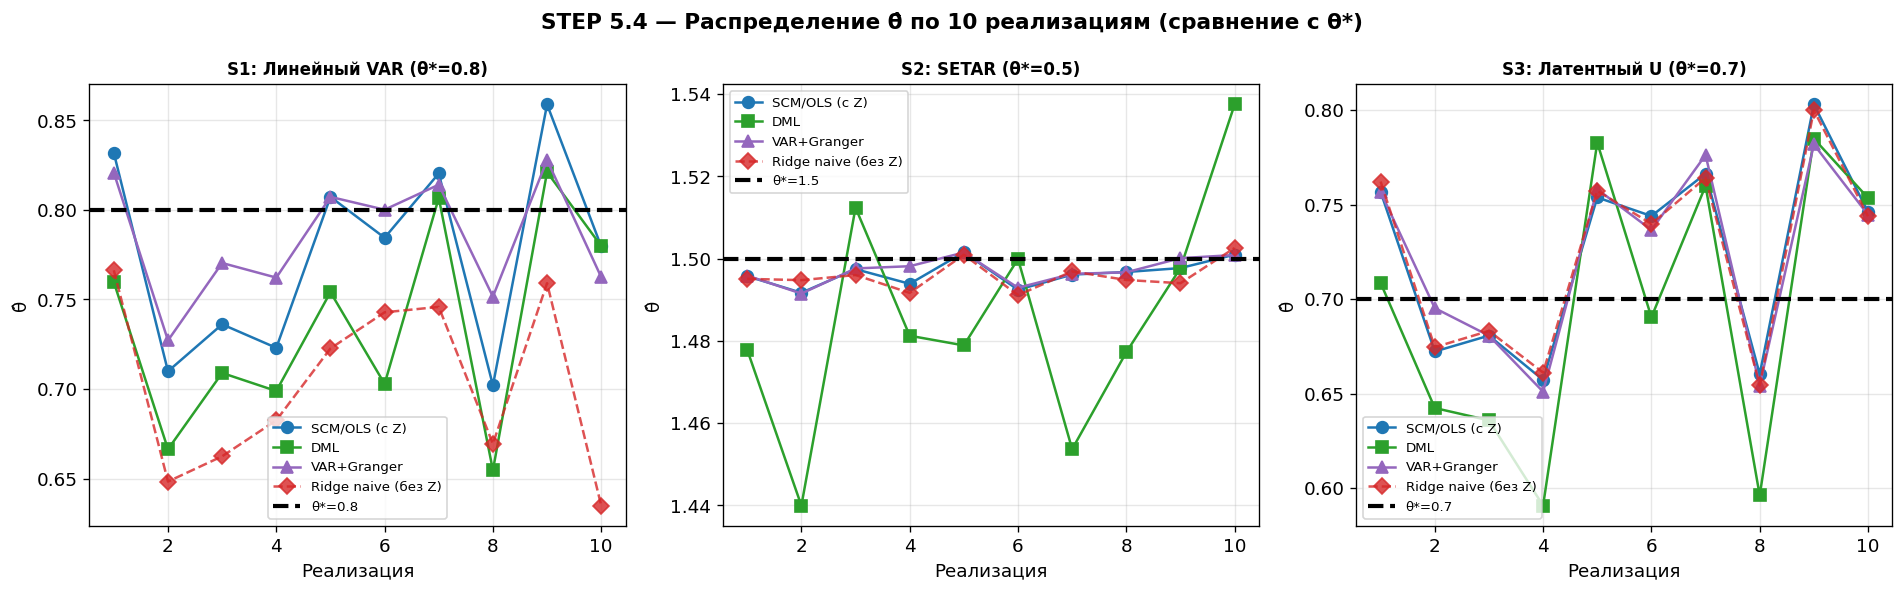

In [20]:
# ── Scatter θ̂ по реализациям (Expert vs Naive vs True) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('STEP 5.4 — Распределение θ̂ по 10 реализациям (сравнение с θ*)',
             fontsize=13, fontweight='bold')

scen_labels = {'scenario1':'S1: Линейный VAR (θ*=0.8)',
               'scenario2':'S2: SETAR (θ*=0.5)',
               'scenario3':'S3: Латентный U (θ*=0.7)'}

for ax, scen in zip(axes, ['scenario1','scenario2','scenario3']):
    sub = mc_df[mc_df['scenario']==scen]
    true_t = sub['true_theta'].iloc[0]
    x = sub['realization'].values

    ax.plot(x, sub['theta_SCM'],  'o-', color='#1f77b4', lw=1.5, ms=7, label='SCM/OLS (с Z)')
    ax.plot(x, sub['theta_DML'],  's-', color='#2ca02c', lw=1.5, ms=7, label='DML')
    ax.plot(x, sub['theta_VAR'],  '^-', color='#9467bd', lw=1.5, ms=7, label='VAR+Granger')
    ax.plot(x, sub['theta_naive'],'D--',color='#d62728', lw=1.5, ms=7, alpha=0.8, label='Ridge naive (без Z)')
    ax.axhline(true_t, color='black', lw=2.5, ls='--', label=f'θ*={true_t}')

    ax.set_title(scen_labels[scen], fontsize=10, fontweight='bold')
    ax.set_xlabel('Реализация'); ax.set_ylabel('θ̂')
    ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()